In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve
)

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score


In [2]:
df = pd.read_csv("../data/model_ready_data.csv")

X = df.drop(columns=['future_spending'])
y = df['future_spending']


In [ ]:
# K-Fold Cross-Validation 
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

cv_scores = cross_val_score(
    gb,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross-Validation R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std Deviation:", cv_scores.std())


Cross-Validation R² Scores: [0.95616574 0.95579958 0.95646713 0.9561769  0.9557527 ]
Mean CV R²: 0.956072408934682
Std Deviation: 0.0002653602359383651


In [5]:
# Train vs Test Performance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

gb.fit(X_train, y_train)

train_r2 = r2_score(y_train, gb.predict(X_train))
test_r2 = r2_score(y_test, gb.predict(X_test))

print("Train R²:", train_r2)
print("Test R² :", test_r2)


Train R²: 0.9582791406934805
Test R² : 0.9565600910211874


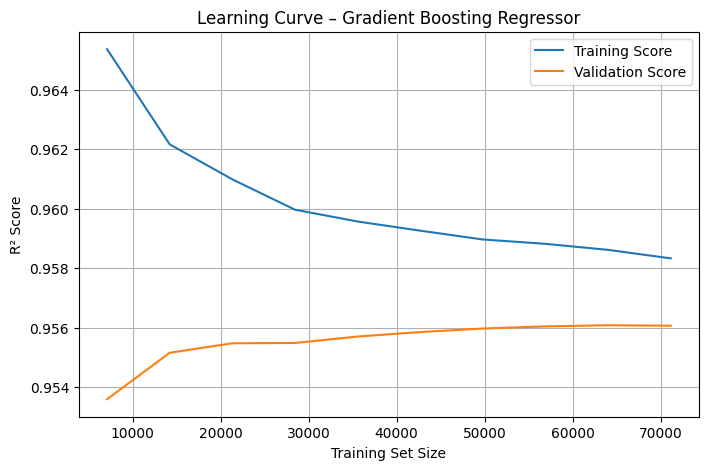

In [6]:
# Learning Curve Analysis
train_sizes, train_scores, test_scores = learning_curve(
    gb,
    X,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.title("Learning Curve – Gradient Boosting Regressor")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()
